# Neural Network Weekly Stock Allocation Project

This project builds a machine learning-based weekly stock selection strategy using momentum and volatility features.

## How to Run

The notebook is designed to run using precomputed feature data stored in:
data/features.csv

## Optional: Rebuild Data from Scratch

If you would like to regenerate the dataset from raw stock data, run the following cell.

Notes:
- This step takes several minutes (~4–5 minutes on high end PC)
- Requires internet connection (uses Yahoo Finance API)
- Not required to run the project

If you do NOT run it, the notebook will use the included `features.csv`.

In [ ]:
REBUILD_DATA = False  # Set to True if you want to rebuild the dataset

if REBUILD_DATA:
    from data_loader import (
        get_sp500_tickers,
        download_price_data,
        convert_to_weekly_prices,
        calculate_weekly_returns
    )

    from features import (
        create_feature_table,
        clean_feature_table
    )

    print("Rebuilding dataset... This may take several minutes.")

    tickers = get_sp500_tickers(limit=500)

    daily_prices = download_price_data(
        tickers,
        start_date="2020-01-01",
        end_date="2025-01-01"
    )

    weekly_prices = convert_to_weekly_prices(daily_prices)

    feature_df = create_feature_table(weekly_prices)
    clean_df = clean_feature_table(feature_df)

    clean_df.to_csv("data/features.csv", index=False)

    print("Feature data rebuilt and saved to data/features.csv")

else:
    print("Skipping data rebuild. Using existing data/features.csv")

Skipping data rebuild. Using existing data/features.csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

from model import (
    split_train_test_by_date,
    prepare_train_test_data,
    build_model,
    train_model
)

import backtest
importlib.reload(backtest)

<module 'backtest' from 'd:\\551project\\momentum_stock_picker\\backtest.py'>

In [2]:
clean_df = pd.read_csv("data/features.csv", parse_dates=["date"])

print("Feature data shape:", clean_df.shape)
clean_df.head()

Feature data shape: (126480, 11)


,date,ticker,price,weekly_return,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,target,score
0,2020-01-31,A,78.967941,-0.064582,0.007389,-0.064582,-0.083888,-0.023767,0.046904,1,-1.063023
1,2020-01-31,AAPL,74.608574,-0.027646,0.036443,-0.027646,-0.028927,0.040615,0.031357,1,0.193917
2,2020-01-31,ABBV,62.992363,-0.030165,0.139101,-0.030165,-0.079318,-0.074243,0.026319,1,-2.534141
3,2020-01-31,ABT,77.826874,-0.036062,0.008377,-0.036062,-0.020899,0.018863,0.035099,1,-0.115079
4,2020-01-31,ACGL,41.991680,-0.018449,0.045063,-0.018449,-0.022360,0.018685,0.023797,1,-0.044152


In [3]:
train_df, test_df = split_train_test_by_date(clean_df, split_date="2024-01-01")

X_train, y_train, X_test, y_test, scaler = prepare_train_test_data(train_df, test_df)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Testing period:", test_df["date"].min(), "to", test_df["date"].max())

Train shape: (100616, 5)
Test shape: (25864, 5)
Training period: 2020-01-31 00:00:00 to 2023-12-29 00:00:00
Testing period: 2024-01-05 00:00:00 to 2024-12-27 00:00:00


In [4]:
nn_model = build_model(input_dim=X_train.shape[1])

nn_model = train_model(
    nn_model,
    X_train,
    y_train,
    epochs=10,
    batch_size=64
)

Epoch 1/10


d:\cpe 551\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1573/1573 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step - accuracy: 0.5336 - loss: 0.6904
Epoch 2/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.5379 - loss: 0.6890
Epoch 3/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - accuracy: 0.5383 - loss: 0.6885
Epoch 4/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 575us/step - accuracy: 0.5386 - loss: 0.6882
Epoch 5/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 567us/step - accuracy: 0.5403 - loss: 0.6877
Epoch 6/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step - accuracy: 0.5409 - loss: 0.6873
Epoch 7/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.5417 - loss: 0.6870
Epoch 8/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step - accuracy: 0.5423 - loss: 0.6868
Epoch 9/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.5419 - loss: 0.6867
Epoch 10/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.5427 - loss: 0.6867


In [5]:
test_loss, test_accuracy = nn_model.evaluate(X_test, y_test, verbose=0)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

Test accuracy: 0.5351840257644653
Test loss: 0.6913006901741028


In [6]:
weekly_results_df, selected_stocks_df = backtest.run_backtest(
    test_df,
    nn_model,
    scaler=scaler
)

weekly_results_df.to_csv("outputs/weekly_results.csv", index=False)
selected_stocks_df.to_csv("outputs/selected_stocks.csv", index=False)

print("Weekly results:")
display(weekly_results_df.head())

print("Selected stocks:")
display(selected_stocks_df.head())

Weekly results:


,date,strategy_return,benchmark_return,num_selected,avg_prediction
0,2024-01-05,0.016017,0.006222,10,0.549102
1,2024-01-12,-0.014786,0.001230,10,0.540045
2,2024-01-19,-0.001088,0.009634,10,0.538738
3,2024-01-26,0.015739,0.007519,10,0.566671
4,2024-02-02,0.035297,0.008945,10,0.522606


Selected stocks:


,date,ticker,group,prediction,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,score
0,2024-01-05,ABBV,top,0.541300,0.011173,0.046267,0.046469,0.086147,0.021753,3.032423
1,2024-01-05,LLY,top,0.536874,0.039399,0.061123,0.084433,0.034278,0.043899,1.243054
2,2024-01-05,IBKR,top,0.536609,0.005005,0.060555,0.070759,0.057366,0.042317,1.462201
3,2024-01-05,WRB,top,0.534292,-0.020845,0.051471,0.059108,0.051491,0.026379,2.030737
4,2024-01-05,AMGN,top,0.533947,0.011584,0.052010,0.066301,0.125892,0.016314,5.680496


In [7]:
weekly_results_df["strategy_growth"] = (1 + weekly_results_df["strategy_return"]).cumprod()
weekly_results_df["benchmark_growth"] = (1 + weekly_results_df["benchmark_return"]).cumprod()

strategy_avg = weekly_results_df["strategy_return"].mean()
benchmark_avg = weekly_results_df["benchmark_return"].mean()

strategy_win_rate = (weekly_results_df["strategy_return"] > 0).mean()
benchmark_win_rate = (weekly_results_df["benchmark_return"] > 0).mean()

strategy_final_growth = weekly_results_df["strategy_growth"].iloc[-1]
benchmark_final_growth = weekly_results_df["benchmark_growth"].iloc[-1]

print("Strategy average weekly return:", strategy_avg)
print("Benchmark average weekly return:", benchmark_avg)
print("Strategy win rate:", strategy_win_rate)
print("Benchmark win rate:", benchmark_win_rate)
print("Strategy final growth of $1:", strategy_final_growth)
print("Benchmark final growth of $1:", benchmark_final_growth)

Strategy average weekly return: 0.01064235958297546
Benchmark average weekly return: 0.0041533172121983345
Strategy win rate: 0.6078431372549019
Benchmark win rate: 0.6078431372549019
Strategy final growth of $1: 1.6670570330017125
Benchmark final growth of $1: 1.2267495268637354


In [8]:
weekly_report_rows = []

for week in sorted(test_df["date"].unique())[:-1]:
    week_data = test_df[test_df["date"] == week].copy()
    
    if len(week_data) < 30:
        continue

    sorted_data = week_data.sort_values("weekly_return")

    bottom_15 = sorted_data.head(15)["ticker"].tolist()
    top_15 = sorted_data.tail(15)["ticker"].tolist()

    selected_week = selected_stocks_df[selected_stocks_df["date"] == week]

    chosen_top_5 = selected_week[selected_week["group"] == "top"]["ticker"].tolist()
    chosen_bottom_5 = selected_week[selected_week["group"] == "bottom"]["ticker"].tolist()

    result_week = weekly_results_df[weekly_results_df["date"] == week]

    if len(result_week) == 0:
        continue

    weekly_report_rows.append({
        "date": week,
        "top_15_previous_week": ", ".join(top_15),
        "bottom_15_previous_week": ", ".join(bottom_15),
        "chosen_top_5": ", ".join(chosen_top_5),
        "chosen_bottom_5": ", ".join(chosen_bottom_5),
        "all_chosen_10": ", ".join(chosen_top_5 + chosen_bottom_5),
        "strategy_return": result_week["strategy_return"].iloc[0],
        "benchmark_return": result_week["benchmark_return"].iloc[0],
        "avg_prediction": result_week["avg_prediction"].iloc[0],
        "num_selected": result_week["num_selected"].iloc[0]
    })

weekly_report_df = pd.DataFrame(weekly_report_rows)

weekly_report_df.to_csv("outputs/full_weekly_stock_report.csv", index=False)

weekly_report_df.head()

,date,top_15_previous_week,bottom_15_previous_week,chosen_top_5,chosen_bottom_5,all_chosen_10,strategy_return,benchmark_return,avg_prediction,num_selected
0,2024-01-05,"ABBV, CI, CAH, WYNN, EG, WRB, AMGN, C, IBKR, L...","SATS, XYZ, CVNA, COIN, NCLH, NXPI, ON, MPWR, G...","ABBV, LLY, IBKR, WRB, AMGN","SATS, COIN, MPWR, ON, AMAT","ABBV, LLY, IBKR, WRB, AMGN, SATS, COIN, MPWR, ...",0.016017,0.006222,0.549102,10
1,2024-01-12,"CIEN, NOW, CRM, DECK, ANET, APP, UBER, DASH, F...","COIN, BA, PSKY, CVNA, ES, TSLA, MOS, HPE, HOOD...","NOW, CRM, APP, UBER, DASH","ALB, TSLA, NEM, BA, CVS","NOW, CRM, APP, UBER, DASH, ALB, TSLA, NEM, BA,...",-0.014786,0.001230,0.540045,10
2,2024-01-19,"TRV, VRT, QCOM, NVDA, LRCX, CDNS, MPWR, FAST, ...","FSLR, ALB, HUM, AES, EXE, NEM, EL, EQT, EVRG, ...","CDNS, WDC, QCOM, FAST, KLAC","NEM, HUM, FSLR, AES, APA","CDNS, WDC, QCOM, FAST, KLAC, NEM, HUM, FSLR, A...",-0.001088,0.009634,0.538738,10
3,2024-01-26,"COF, FTNT, PSX, APTV, TEL, IBM, UAL, AXP, RMD,...","ADM, TSLA, DD, MMM, HUM, SATS, DHI, INTC, GILD...","PSX, SMCI, UAL, COF, HAL","SATS, HUM, GILD, PYPL, NOC","PSX, SMCI, UAL, COF, HAL, SATS, HUM, GILD, PYP...",0.015739,0.007519,0.566671,10
4,2024-02-02,"HCA, VST, ETN, SYK, TT, GWW, GM, FIX, FTV, DEC...","CHTR, CHRW, SW, ROK, UPS, IP, GEN, BXP, AFL, T...","SMCI, GM, HCA, SYK, VST","TER, GOOG, GEN, AFL, HAL","SMCI, GM, HCA, SYK, VST, TER, GOOG, GEN, AFL, HAL",0.035297,0.008945,0.522606,10


In [9]:
stock_selection_counts = selected_stocks_df["ticker"].value_counts().reset_index()
stock_selection_counts.columns = ["ticker", "times_selected"]

stock_selection_counts.to_csv("outputs/stock_selection_counts.csv", index=False)

stock_selection_counts.head(20)

,ticker,times_selected
0,SMCI,12
1,ALB,9
2,MRNA,9
3,VRT,9
4,APP,9
5,VST,8
6,SATS,8
7,COIN,8
8,HOOD,8
9,COHR,8


In [10]:
selected_stocks_detailed = selected_stocks_df.sort_values(
    ["date", "group", "prediction"],
    ascending=[True, True, False]
)

selected_stocks_detailed.to_csv("outputs/selected_stocks_detailed.csv", index=False)

selected_stocks_detailed.head(20)

,date,ticker,group,prediction,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,score
5,2024-01-05,SATS,bottom,0.582447,0.270570,-0.237176,-0.112982,-0.030675,0.171370,-0.563757
6,2024-01-05,COIN,bottom,0.569371,-0.150669,-0.114650,-0.122521,0.050198,0.124886,-0.276731
7,2024-01-05,MPWR,bottom,0.558493,0.008310,-0.090032,-0.069210,-0.001454,0.080057,-0.492735
8,2024-01-05,ON,bottom,0.550315,-0.029458,-0.093739,-0.098917,-0.005779,0.090879,-0.564004
9,2024-01-05,AMAT,bottom,0.547369,0.015101,-0.080644,-0.080531,0.008665,0.072379,-0.496084
0,2024-01-05,ABBV,top,0.541300,0.011173,0.046267,0.046469,0.086147,0.021753,3.032423
1,2024-01-05,LLY,top,0.536874,0.039399,0.061123,0.084433,0.034278,0.043899,1.243054
2,2024-01-05,IBKR,top,0.536609,0.005005,0.060555,0.070759,0.057366,0.042317,1.462201
3,2024-01-05,WRB,top,0.534292,-0.020845,0.051471,0.059108,0.051491,0.026379,2.030737
4,2024-01-05,AMGN,top,0.533947,0.011584,0.052010,0.066301,0.125892,0.016314,5.680496


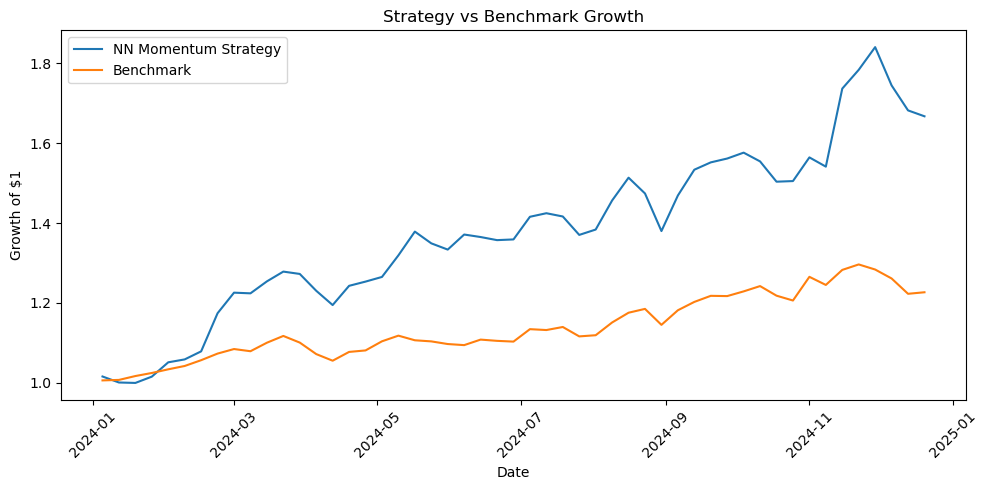

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_results_df["date"],
    weekly_results_df["strategy_growth"],
    label="NN Momentum Strategy"
)
plt.plot(
    weekly_results_df["date"],
    weekly_results_df["benchmark_growth"],
    label="Benchmark"
)
plt.title("Strategy vs Benchmark Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

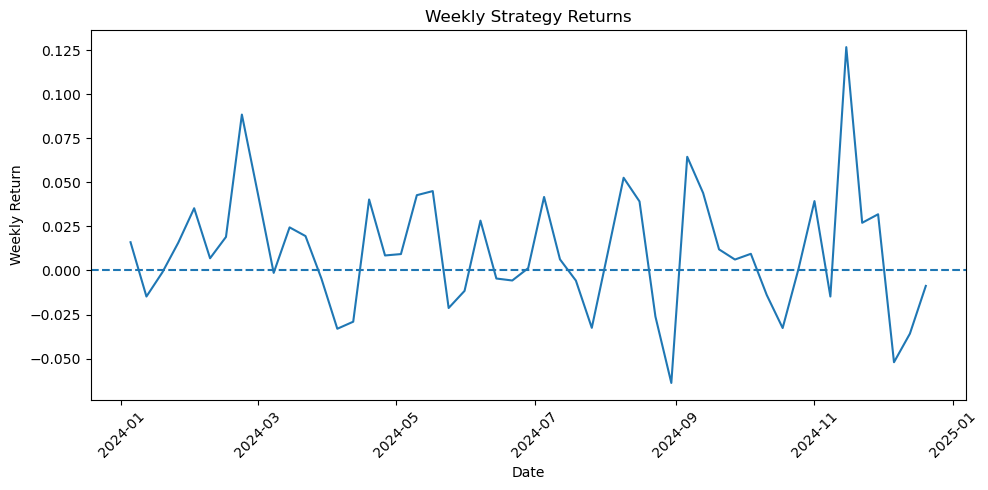

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_results_df["date"],
    weekly_results_df["strategy_return"],
    label="Strategy Weekly Return"
)
plt.axhline(0, linestyle="--")
plt.title("Weekly Strategy Returns")
plt.xlabel("Date")
plt.ylabel("Weekly Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

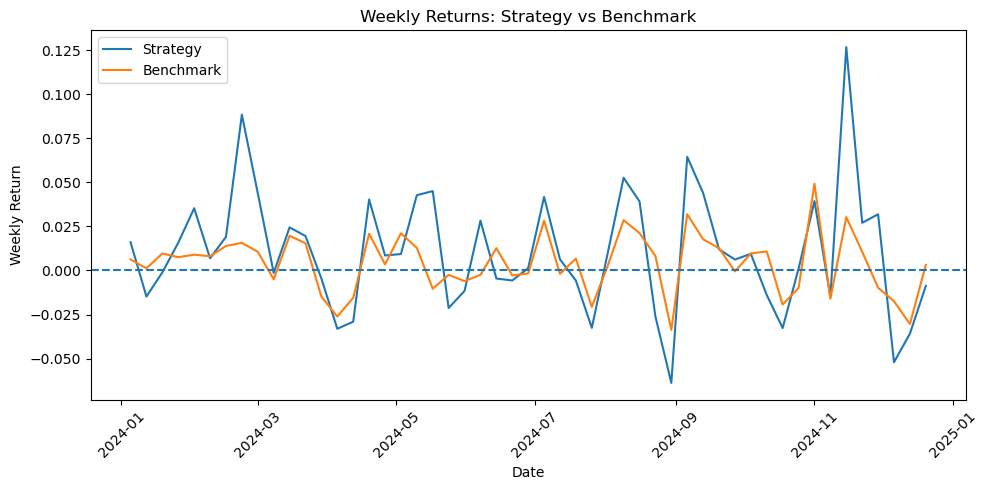

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_results_df["date"],
    weekly_results_df["strategy_return"],
    label="Strategy"
)
plt.plot(
    weekly_results_df["date"],
    weekly_results_df["benchmark_return"],
    label="Benchmark"
)
plt.axhline(0, linestyle="--")
plt.title("Weekly Returns: Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Weekly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

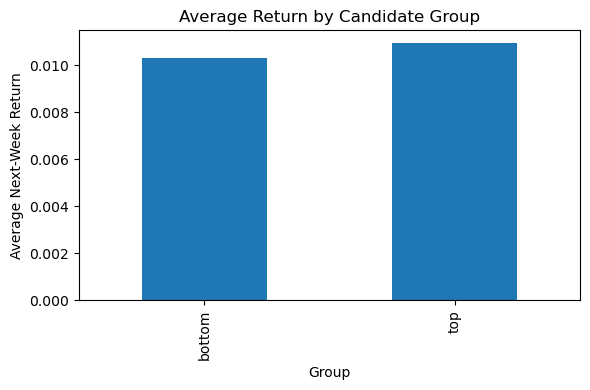

group
bottom    0.010335
top       0.010949
Name: next_week_return, dtype: float64

In [14]:
group_returns = selected_stocks_df.groupby("group")["next_week_return"].mean()

plt.figure(figsize=(6, 4))
group_returns.plot(kind="bar")
plt.title("Average Return by Candidate Group")
plt.xlabel("Group")
plt.ylabel("Average Next-Week Return")
plt.tight_layout()
plt.show()

group_returns

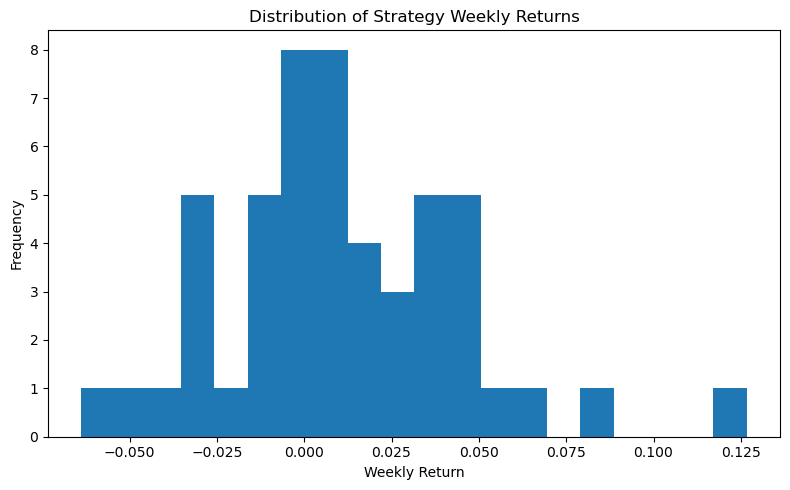

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(weekly_results_df["strategy_return"], bins=20)
plt.title("Distribution of Strategy Weekly Returns")
plt.xlabel("Weekly Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [16]:
best_picks = selected_stocks_df.sort_values(
    "next_week_return",
    ascending=False
).head(10)

best_picks

,date,ticker,group,prediction,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,score
456,2024-11-15,SMCI,bottom,0.619250,0.784177,-0.242251,-0.286756,-0.606856,0.202608,-2.160277
71,2024-02-23,DELL,top,0.530278,0.378971,0.072913,0.048144,0.072786,0.041340,1.578615
40,2024-02-02,SMCI,top,0.529300,0.277177,0.222461,0.369119,0.984151,0.057531,11.231852
436,2024-11-01,HOOD,bottom,0.562099,0.274093,-0.114191,-0.106597,0.047182,0.107033,-0.291472
5,2024-01-05,SATS,bottom,0.582447,0.270570,-0.237176,-0.112982,-0.030675,0.171370,-0.563757
362,2024-09-13,VST,top,0.529300,0.264015,0.160787,0.001405,0.078135,0.127470,0.561623
193,2024-05-17,MRNA,top,0.529300,0.253649,0.132896,0.063200,0.310522,0.098201,2.042701
84,2024-03-01,COIN,top,0.499047,0.247121,0.239728,0.141201,0.592401,0.159622,2.419870
156,2024-04-19,VRT,bottom,0.542920,0.246367,-0.105853,-0.121045,-0.090788,0.062395,-1.646173
316,2024-08-09,SMCI,bottom,0.559357,0.235946,-0.185528,-0.285640,-0.440899,0.034848,-9.821722


In [17]:
worst_picks = selected_stocks_df.sort_values(
    "next_week_return",
    ascending=True
).head(10)

worst_picks

,date,ticker,group,prediction,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,score
480,2024-12-06,SMCI,top,0.727608,-0.170271,0.345895,0.325188,0.791599,0.448409,1.254232
287,2024-07-19,CRWD,bottom,0.529057,-0.160021,-0.178714,-0.217409,-0.198802,0.089949,-2.225072
6,2024-01-05,COIN,bottom,0.569371,-0.150669,-0.114650,-0.122521,0.050198,0.124886,-0.276731
296,2024-07-26,CRWD,bottom,0.571375,-0.149399,-0.160021,-0.310137,-0.331507,0.093145,-3.118663
343,2024-08-30,INTC,top,0.532803,-0.142922,0.073028,0.056061,0.032580,0.069574,0.684814
347,2024-08-30,NVDA,bottom,0.586551,-0.138561,-0.077298,-0.041821,0.112800,0.115199,0.246265
172,2024-05-03,SATS,top,0.525393,-0.122636,0.090625,0.199313,0.312030,0.033494,6.963661
345,2024-08-30,SMCI,bottom,0.628853,-0.117066,-0.286250,-0.303912,-0.299288,0.227792,-1.307933
348,2024-08-30,CVNA,bottom,0.553056,-0.114261,-0.057329,-0.034054,0.097813,0.087345,0.311338
411,2024-10-18,PHM,top,0.533444,-0.111178,0.070690,0.068847,0.050613,0.041167,1.456342


In [18]:
selected_timeline = selected_stocks_df.groupby("date").agg({
    "ticker": lambda x: ", ".join(x),
    "next_week_return": "mean",
    "prediction": "mean"
}).reset_index()

selected_timeline = selected_timeline.rename(columns={
    "ticker": "selected_stocks",
    "next_week_return": "portfolio_return",
    "prediction": "avg_prediction"
})

selected_timeline.to_csv("outputs/selected_timeline.csv", index=False)

selected_timeline.head(10)

,date,selected_stocks,portfolio_return,avg_prediction
0,2024-01-05,"ABBV, LLY, IBKR, WRB, AMGN, SATS, COIN, MPWR, ...",0.016017,0.549102
1,2024-01-12,"NOW, CRM, APP, UBER, DASH, ALB, TSLA, NEM, BA,...",-0.014786,0.540045
2,2024-01-19,"CDNS, WDC, QCOM, FAST, KLAC, NEM, HUM, FSLR, A...",-0.001088,0.538738
3,2024-01-26,"PSX, SMCI, UAL, COF, HAL, SATS, HUM, GILD, PYP...",0.015739,0.566671
4,2024-02-02,"SMCI, GM, HCA, SYK, VST, TER, GOOG, GEN, AFL, HAL",0.035297,0.522606
5,2024-02-09,"WSM, SMCI, EMR, GEHC, GNRC, LITE, FOX, TTWO, P...",0.006915,0.530908
6,2024-02-16,"SW, TPR, VTRS, LDOS, DVA, WST, GNRC, MGM, MU, NOW",0.019024,0.529767
7,2024-02-23,"EQT, DELL, SMCI, NVDA, EME, PLTR, PSKY, TSLA, ...",0.088418,0.538843
8,2024-03-01,"HOOD, CVNA, FIX, ERIE, COIN, VTRS, PODD, CBOE,...",0.043817,0.529476
9,2024-03-08,"NEM, D, SBAC, RMD, EW, PANW, WDAY, AVGO, ALB, ...",-0.001372,0.554868


In [19]:
week_to_view = selected_stocks_df["date"].unique()[0]

one_week_view = selected_stocks_df[
    selected_stocks_df["date"] == week_to_view
].sort_values("prediction", ascending=False)

one_week_view

,date,ticker,group,prediction,next_week_return,mom_1w,mom_2w,mom_4w,vol_4w,score
5,2024-01-05,SATS,bottom,0.582447,0.270570,-0.237176,-0.112982,-0.030675,0.171370,-0.563757
6,2024-01-05,COIN,bottom,0.569371,-0.150669,-0.114650,-0.122521,0.050198,0.124886,-0.276731
7,2024-01-05,MPWR,bottom,0.558493,0.008310,-0.090032,-0.069210,-0.001454,0.080057,-0.492735
8,2024-01-05,ON,bottom,0.550315,-0.029458,-0.093739,-0.098917,-0.005779,0.090879,-0.564004
9,2024-01-05,AMAT,bottom,0.547369,0.015101,-0.080644,-0.080531,0.008665,0.072379,-0.496084
0,2024-01-05,ABBV,top,0.541300,0.011173,0.046267,0.046469,0.086147,0.021753,3.032423
1,2024-01-05,LLY,top,0.536874,0.039399,0.061123,0.084433,0.034278,0.043899,1.243054
2,2024-01-05,IBKR,top,0.536609,0.005005,0.060555,0.070759,0.057366,0.042317,1.462201
3,2024-01-05,WRB,top,0.534292,-0.020845,0.051471,0.059108,0.051491,0.026379,2.030737
4,2024-01-05,AMGN,top,0.533947,0.011584,0.052010,0.066301,0.125892,0.016314,5.680496


In [21]:
print("FINAL RESULTS")
print("----------------------")
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)
print("Strategy average weekly return:", strategy_avg)
print("Benchmark average weekly return:", benchmark_avg)
print("Strategy win rate:", strategy_win_rate)
print("Benchmark win rate:", benchmark_win_rate)
print("Strategy final growth of $1:", strategy_final_growth)
print("Benchmark final growth of $1:", benchmark_final_growth)
print("Number of backtest weeks:", len(weekly_results_df))
print("Number of selected stock observations:", len(selected_stocks_df))

FINAL RESULTS
----------------------
Test accuracy: 0.5351840257644653
Test loss: 0.6913006901741028
Strategy average weekly return: 0.01064235958297546
Benchmark average weekly return: 0.0041533172121983345
Strategy win rate: 0.6078431372549019
Benchmark win rate: 0.6078431372549019
Strategy final growth of $1: 1.6670570330017125
Benchmark final growth of $1: 1.2267495268637354
Number of backtest weeks: 51
Number of selected stock observations: 510
